<h1 style="text-align:center; color:#4CAF50; font-weight:bold;">
student_performance_prediction
</h1>

<hr style="border: 2px solid #4CAF50; width: 80%; margin: auto;">

<div style="text-align: center">
    <img src="summary.png" alt="Student Performance Prediction" style="max-width: 55%; height: auto;">
</div>

In [1]:
import numpy as np 
import pandas as pd
# imports for Visualization 
import matplotlib.pyplot as plt
import seaborn as sns
import math
# imports for Data Preprocessing 
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv('student_performance_prediction_dataset-2.csv') 
df.head()

,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,6.811654,7.316867,9.045441,7.762145,1.549443,4.018412,Medium,Master,Yes,Mobile,Private,Coding Club,59.248749,D,Pass
1,2,18,Male,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,10.000000,10.000000,9.810884,4.229670,5.458155,3.268642,Medium,Master,Yes,Laptop,Public,NaN,58.595595,D,Pass
2,3,19,Female,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,6.484908,3.618888,10.000000,7.583075,0.000000,2.327293,Low,High School,Yes,Tablet,Private,Music,85.855289,A,Pass
3,4,21,Female,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,6.057978,5.366866,5.935404,4.978907,5.325794,1.163367,Medium,Bachelor,Yes,Laptop,Public,Debate,42.117503,F,Fail
4,5,17,Male,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,9.013332,5.613393,5.431089,5.677695,4.416843,0.411183,High,High School,Yes,Laptop,Private,Debate,62.870474,C,Pass


<h2 style="color:#4CAF50; font-weight:bold;">
1- EDA
</h2>

<hr style="border: 2px solid #4CAF50; width: 10%; margin-left:0;">

In [3]:
print("SHAPE:", df.shape)    

SHAPE: (300000, 25)


In [4]:
print("\nDTYPES:\n", df.dtypes) 


DTYPES:
 student_id                 int64
age                        int64
gender                    object
study_hours              float64
attendance               float64
sleep_hours              float64
previous_grade           float64
assignments_completed    float64
practice_tests_taken     float64
group_study_hours        float64
notes_quality_score      float64
time_management_score    float64
motivation_level         float64
mental_health_score      float64
screen_time              float64
social_media_hours       float64
family_income             object
parent_education          object
internet_access           object
device_type               object
school_type               object
extracurriculars          object
final_grade              float64
grade_category            object
pass_fail                 object
dtype: object


In [5]:
print("\nNULL COUNT:\n", df.isnull().sum())


NULL COUNT:
 student_id                   0
age                          0
gender                       0
study_hours                  0
attendance                   0
sleep_hours                  0
previous_grade               0
assignments_completed        0
practice_tests_taken         0
group_study_hours            0
notes_quality_score          0
time_management_score        0
motivation_level             0
mental_health_score          0
screen_time                  0
social_media_hours           0
family_income                0
parent_education             0
internet_access              0
device_type              15105
school_type                  0
extracurriculars         49981
final_grade                  0
grade_category               4
pass_fail                    0
dtype: int64


In [6]:
print("\nDESCRIBE:\n", df.describe())   


DESCRIBE:
           student_id            age  ...  social_media_hours    final_grade
count  300000.000000  300000.000000  ...       300000.000000  300000.000000
mean   150000.500000      17.999070  ...            2.530258      53.089206
std     86602.684716       1.999235  ...            1.435742      12.225161
min         1.000000      15.000000  ...            0.000000       0.000000
25%     75000.750000      16.000000  ...            1.491633      44.867737
50%    150000.500000      18.000000  ...            2.498493      53.167495
75%    225000.250000      20.000000  ...            3.513496      61.379373
max    300000.000000      21.000000  ...            8.000000     100.000000

[8 rows x 16 columns]


In [7]:
print("\nInformation:\n", df.info() )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   student_id             300000 non-null  int64  
 1   age                    300000 non-null  int64  
 2   gender                 300000 non-null  object 
 3   study_hours            300000 non-null  float64
 4   attendance             300000 non-null  float64
 5   sleep_hours            300000 non-null  float64
 6   previous_grade         300000 non-null  float64
 7   assignments_completed  300000 non-null  float64
 8   practice_tests_taken   300000 non-null  float64
 9   group_study_hours      300000 non-null  float64
 10  notes_quality_score    300000 non-null  float64
 11  time_management_score  300000 non-null  float64
 12  motivation_level       300000 non-null  float64
 13  mental_health_score    300000 non-null  float64
 14  screen_time            300000 non-nu

In [8]:
# To see if data in target column pass_fail is balanced or not 
df['pass_fail'].value_counts()

pass_fail
Pass    180729
Fail    119271
Name: count, dtype: int64

___

<h2 style="color:#4CAF50; font-weight:bold;">
2- Data Visualization 
</h2>

<hr style="border: 2px solid #4CAF50; width: 25%; margin-left:0;">

C:\Users\e\AppData\Local\Temp\ipykernel_16228\2584874262.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pass_fail', data=df, palette=["#4CAF50", "#FF5722"] )


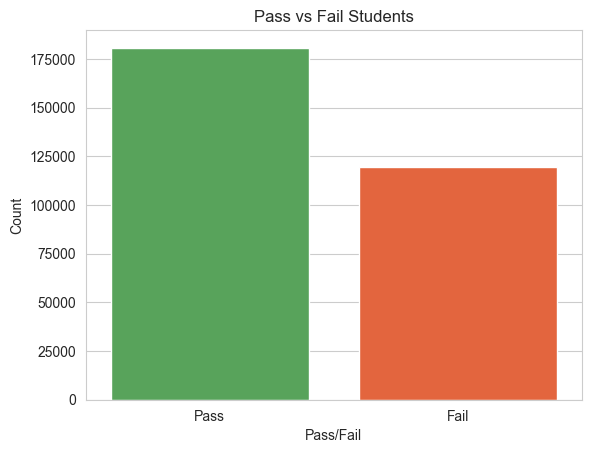

In [55]:
# Visualization of the target variable (pass_fail)
sns.countplot(x='pass_fail', data=df, palette=["#4CAF50", "#FF5722"] )

plt.title("Pass vs Fail Students")
plt.xlabel("Pass/Fail")
plt.ylabel("Count")

plt.show()

In [12]:
# To see if data in target column grade_category is balanced or not 
df['grade_category'].value_counts()

grade_category
F     119267
D      94434
C      61495
B      20910
A       3593
A+       297
Name: count, dtype: int64

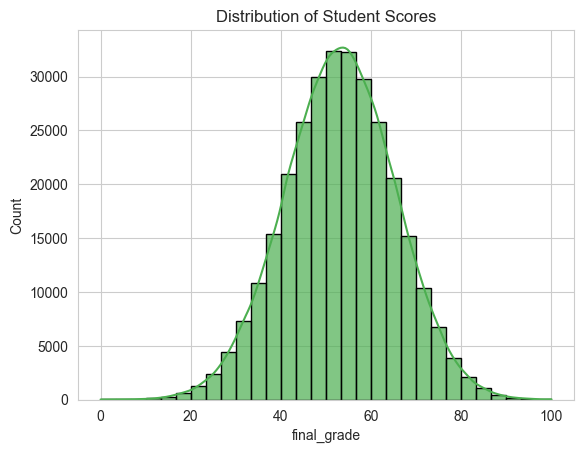

In [57]:
# Visualization of the target variable (grade_category)
sns.histplot(df['final_grade'], bins=30, kde=True, color="#4CAF50", edgecolor='black', alpha=0.7) 
plt.title("Distribution of Student Scores")
plt.show()

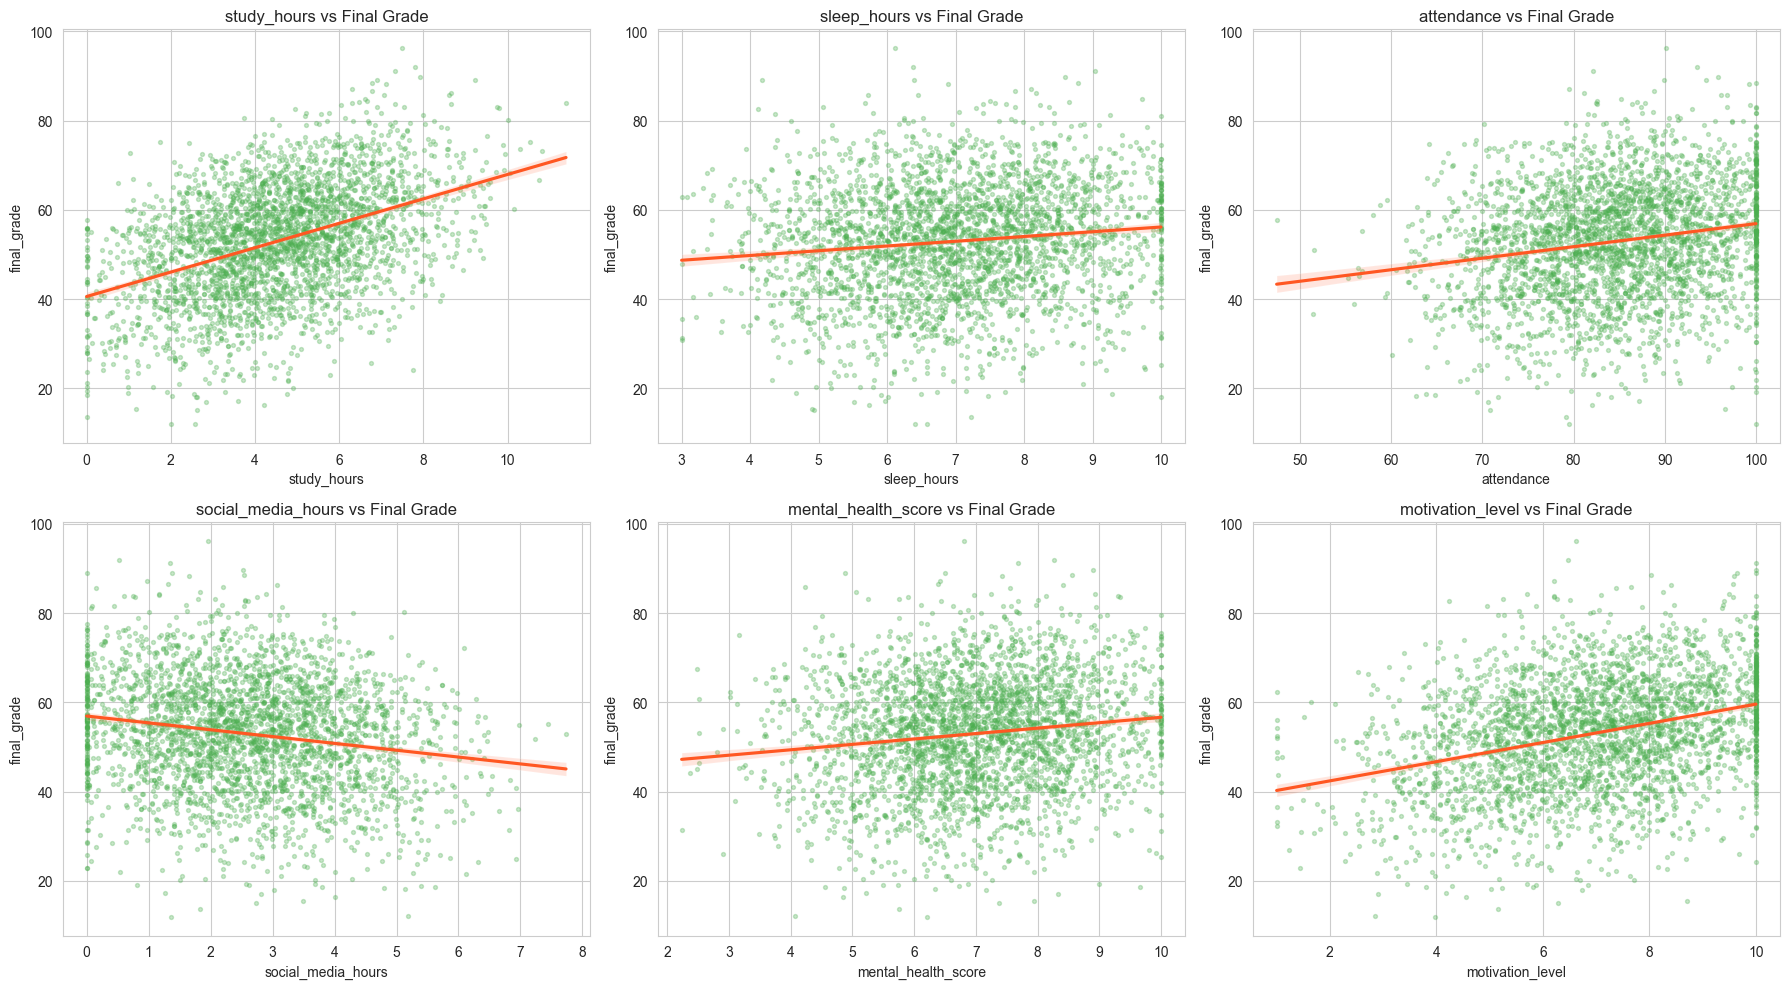

In [58]:
sample = df.sample(n=3000, random_state=42)
# To visualize the relationships between the target variable and the features
# we can create scatter plots with regression lines for each feature against the target
features = [
    'study_hours',
    'sleep_hours',
    'attendance',
    'social_media_hours',
    'mental_health_score',
    'motivation_level'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.regplot(
        data=sample,
        x=col,
        y='final_grade',
        ax=axes[i],
        scatter_kws={'alpha': 0.3, 's': 8, 'color': "#4CAF50"},
        line_kws={'color': "#FF5722"}
    )
    axes[i].set_title(f"{col} vs Final Grade")

plt.tight_layout()
plt.show()

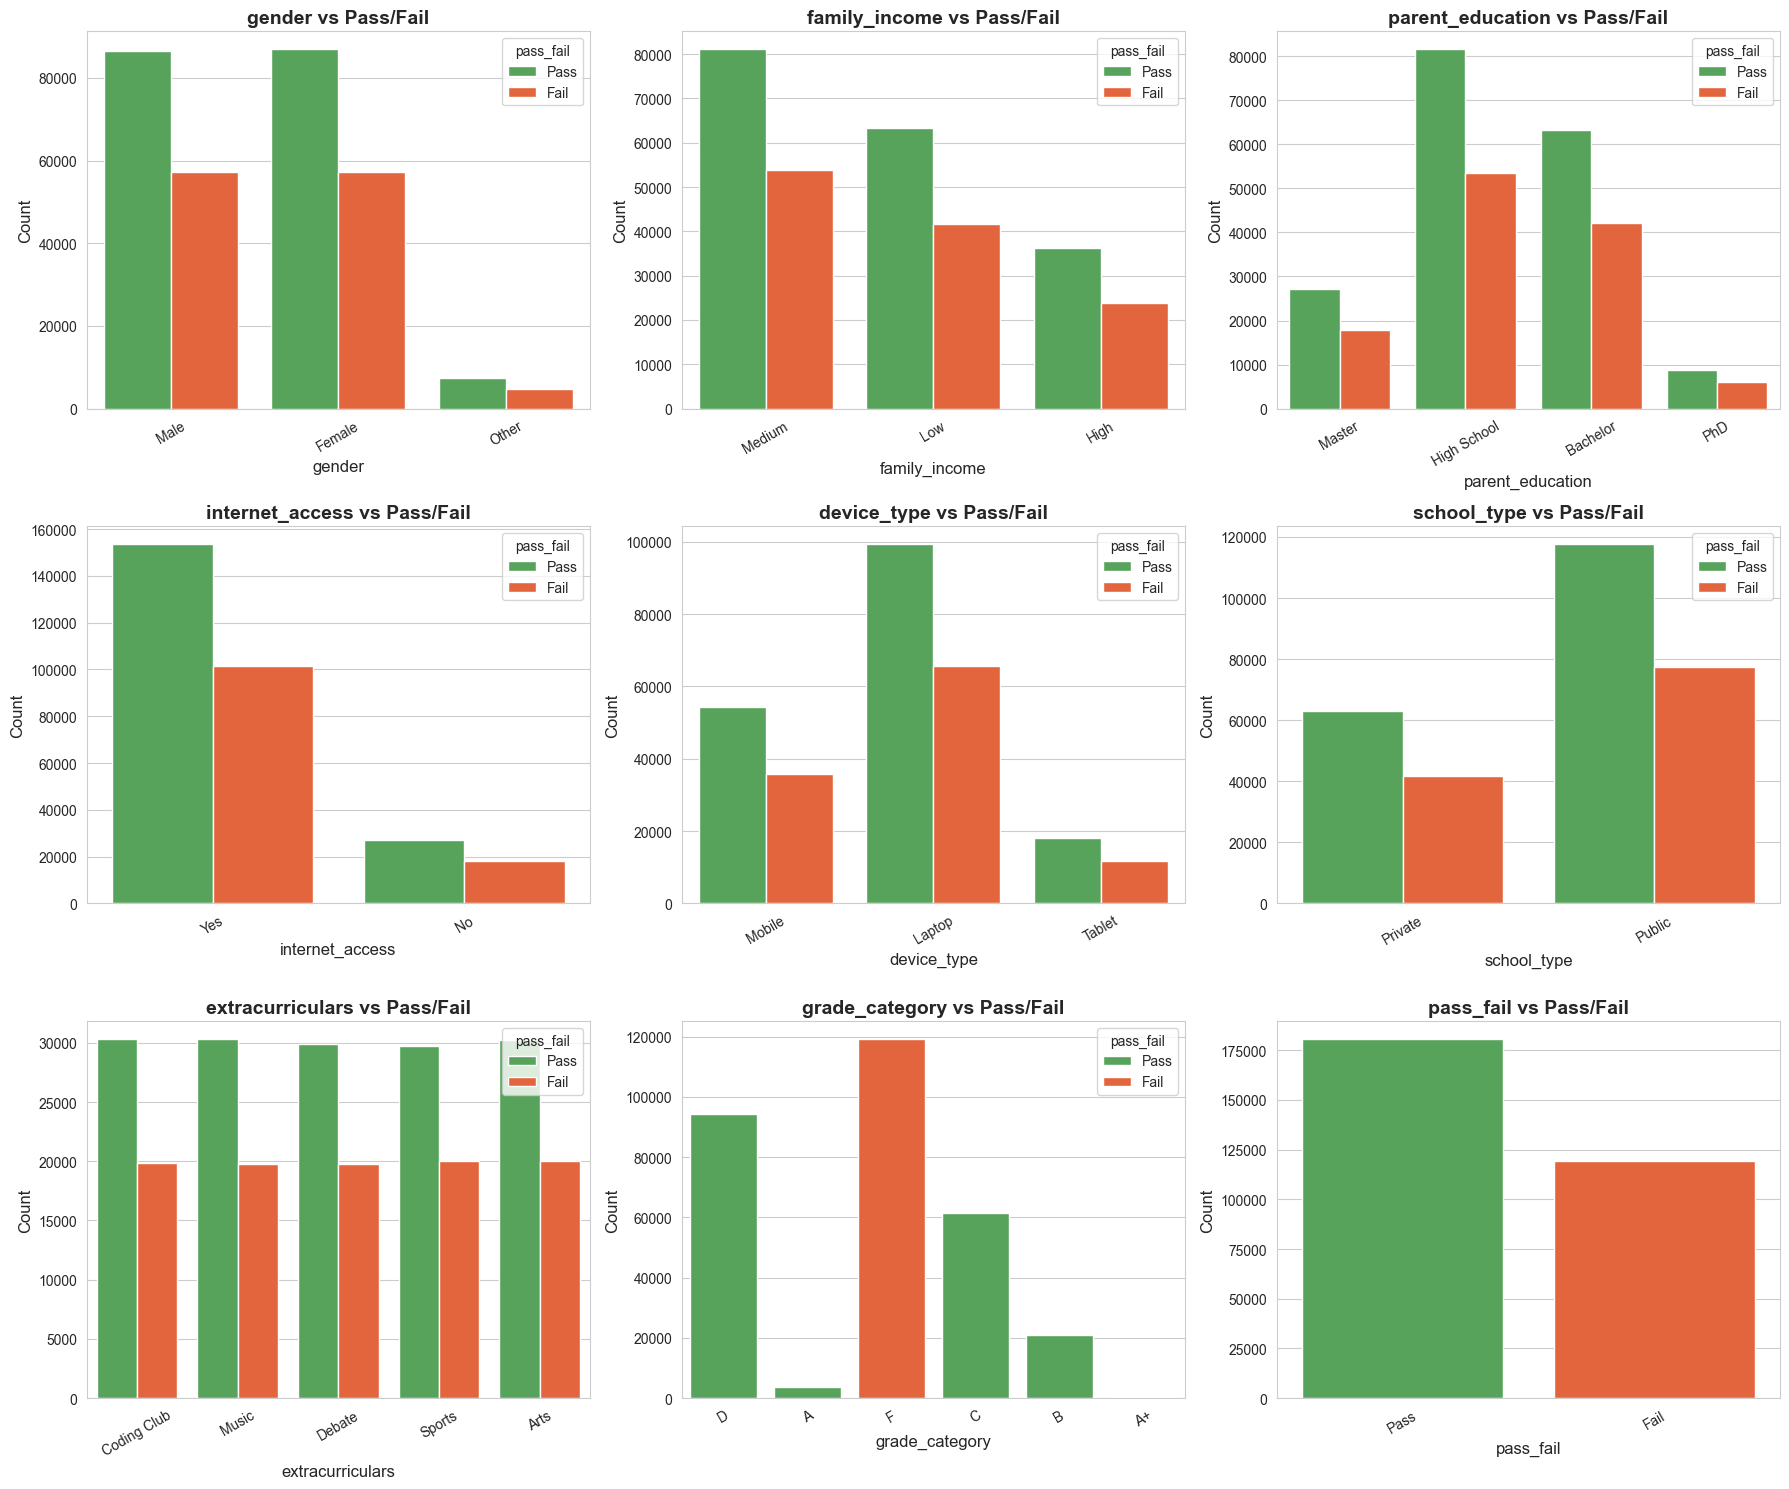

In [59]:
# To visualize the relationships between the target variable and the categorical features
cat_cols = df.select_dtypes(include='object').columns.tolist()

sns.set_style("whitegrid")

n = len(cat_cols)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

palette = ["#4CAF50", "#FF5722"] 

for i, col in enumerate(cat_cols):
    sns.countplot(
        x=col,
        hue='pass_fail',
        data=df,
        ax=axes[i],
        palette=palette
    )
    
    axes[i].set_title(f"{col} vs Pass/Fail", fontsize=14, weight='bold')
    axes[i].tick_params(axis='x', rotation=30)  
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Count", fontsize=12)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

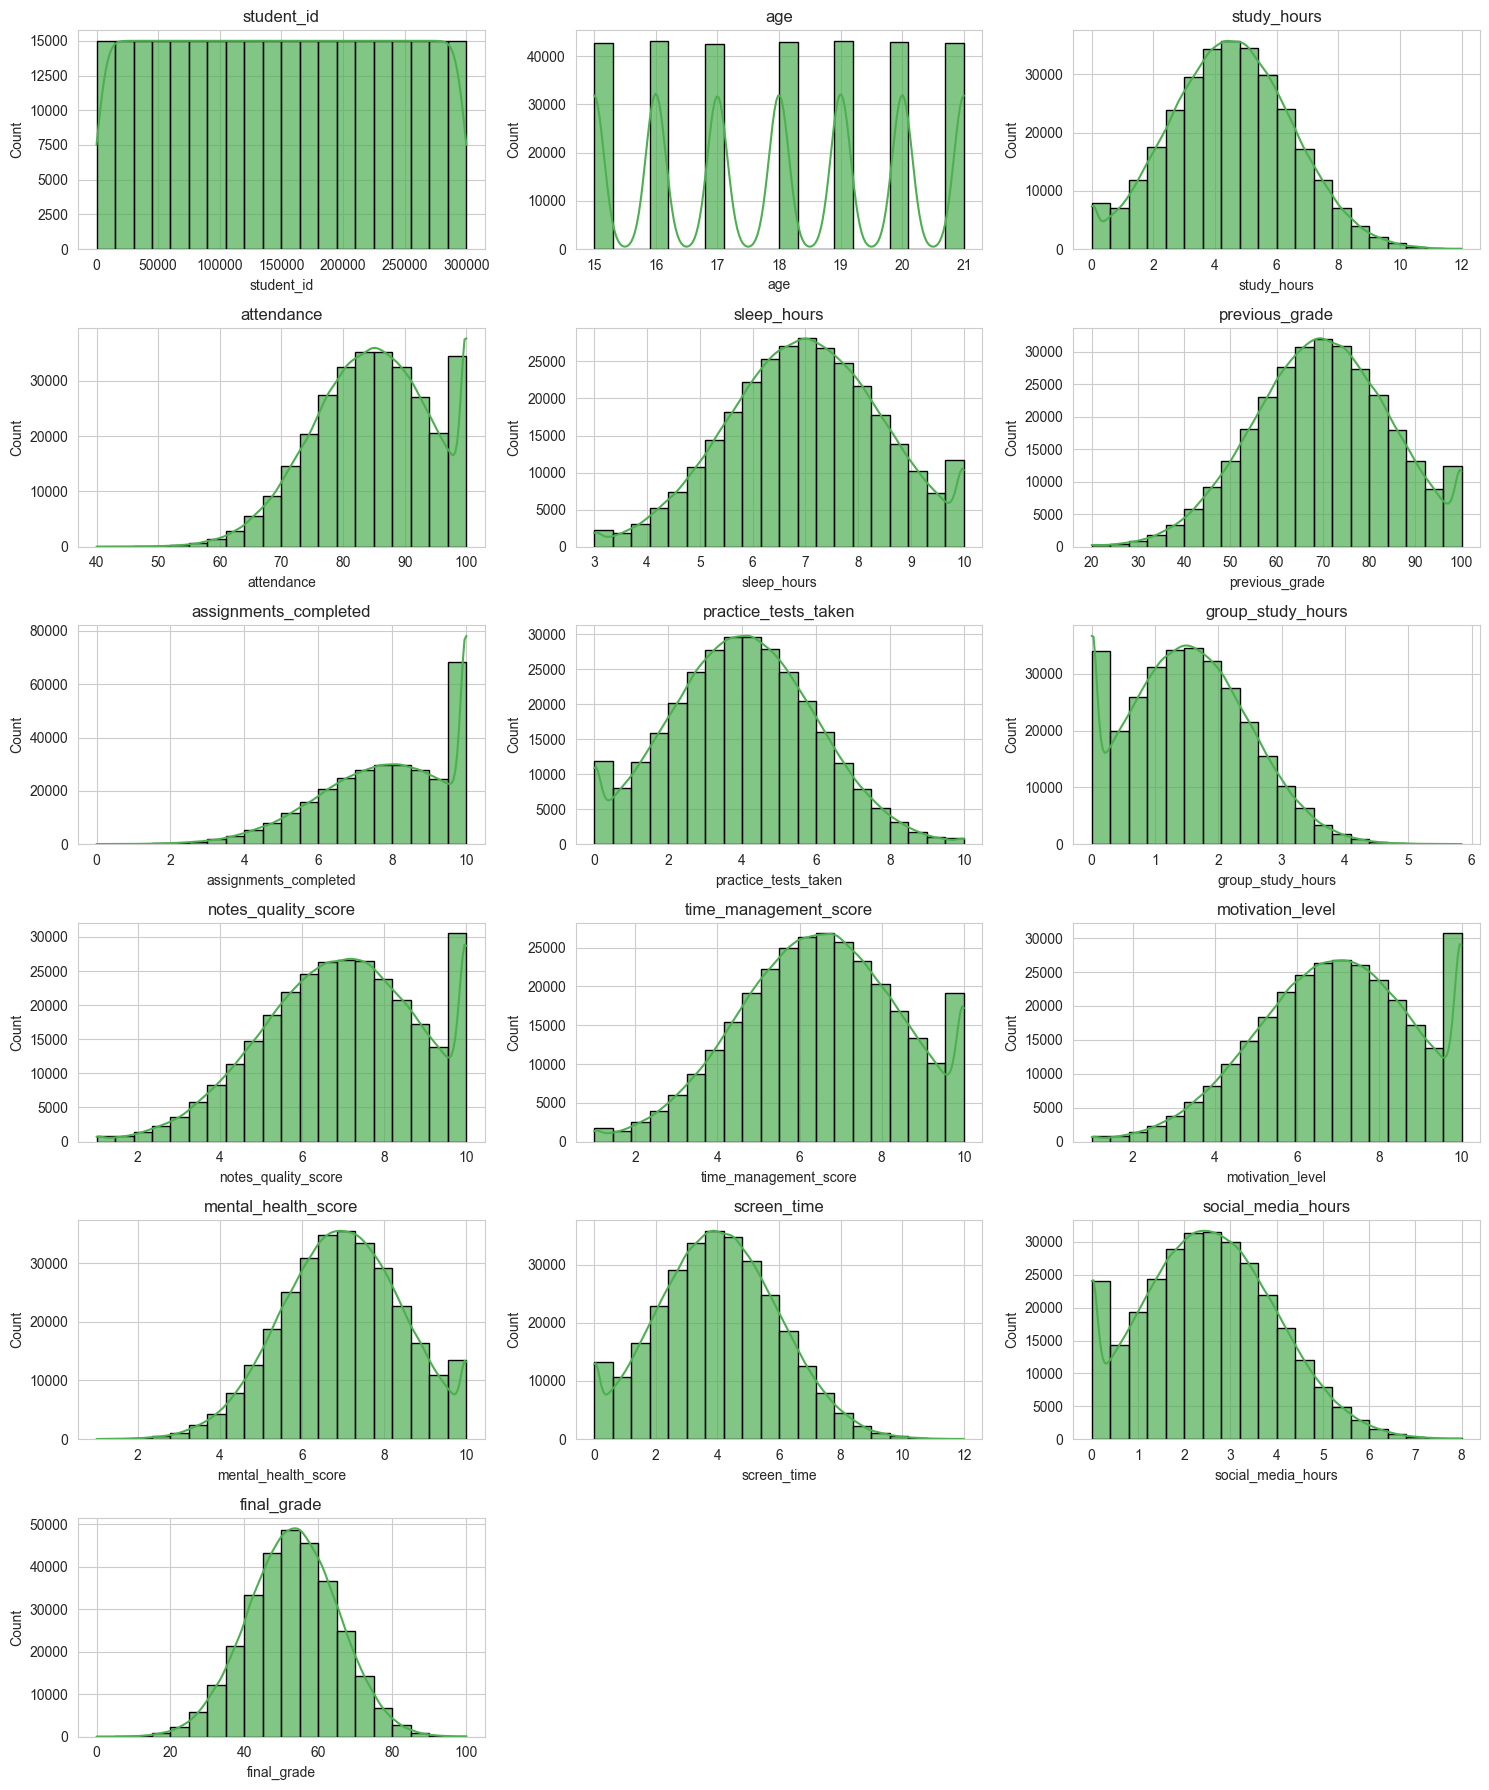

In [60]:
# Histograms for all numerical features to visualize their distributions.
num_cols = df.select_dtypes(include=['int64','float64']).columns
n = len(num_cols)
cols = 3
rows = math.ceil(n / cols)
plt.figure(figsize=(15, rows * 3))
for i, col in enumerate(num_cols):
    plt.subplot(rows, cols, i+1)
    sns.histplot(
        df[col],
        bins=20,
        kde=True,
        color="#4CAF50",
        edgecolor="black",
        alpha=0.7
    )
    plt.title(col)

plt.tight_layout()
plt.show()

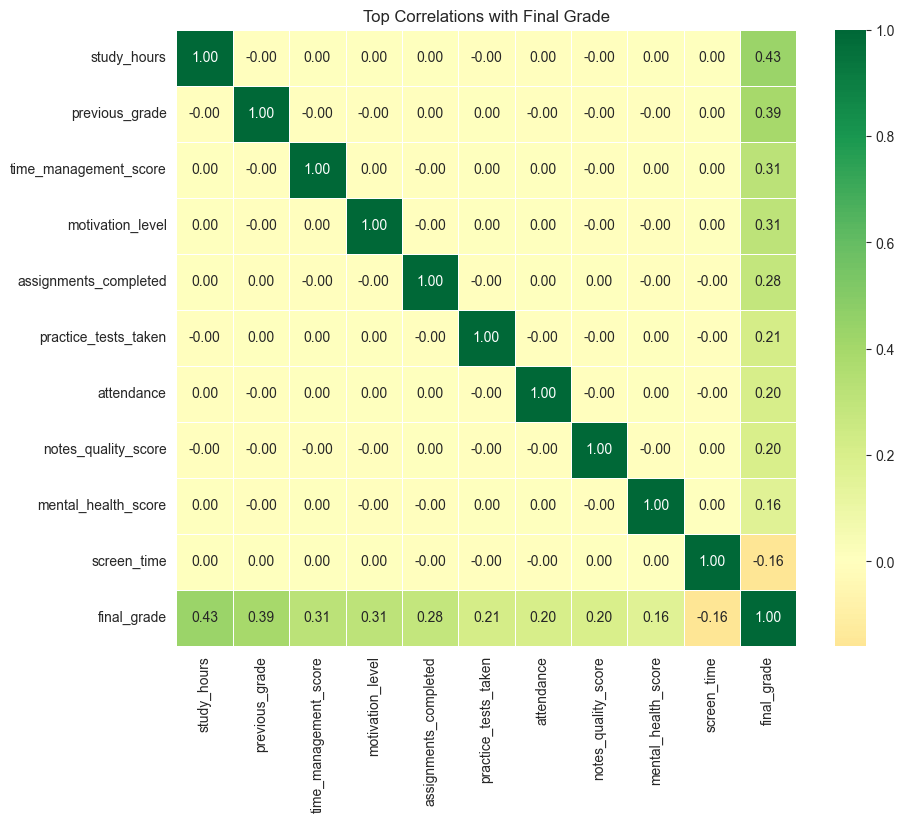

In [61]:
# To visualize the correlation between numerical features and the target variable
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df.copy()
corr = num_df.corr(numeric_only=True)
# Check if 'final_grade' is in the correlation matrix before trying to access it
if "final_grade" in corr.columns:
    target_corr = corr["final_grade"].drop("final_grade")
# Sort the correlations by absolute value to get the most relevant features
    target_corr = target_corr.sort_values(key=np.abs, ascending=False)
# Select the top 10 features most correlated with final_grade
    top_features = target_corr.index[:10].tolist() + ["final_grade"]
# Create a subset of the correlation matrix for these top features
    subset = corr.loc[top_features, top_features]
# Visualize the correlation matrix using a heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        subset,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",   
        center=0,
        linewidths=0.5
    )
    plt.title("Top Correlations with Final Grade")
    plt.show()

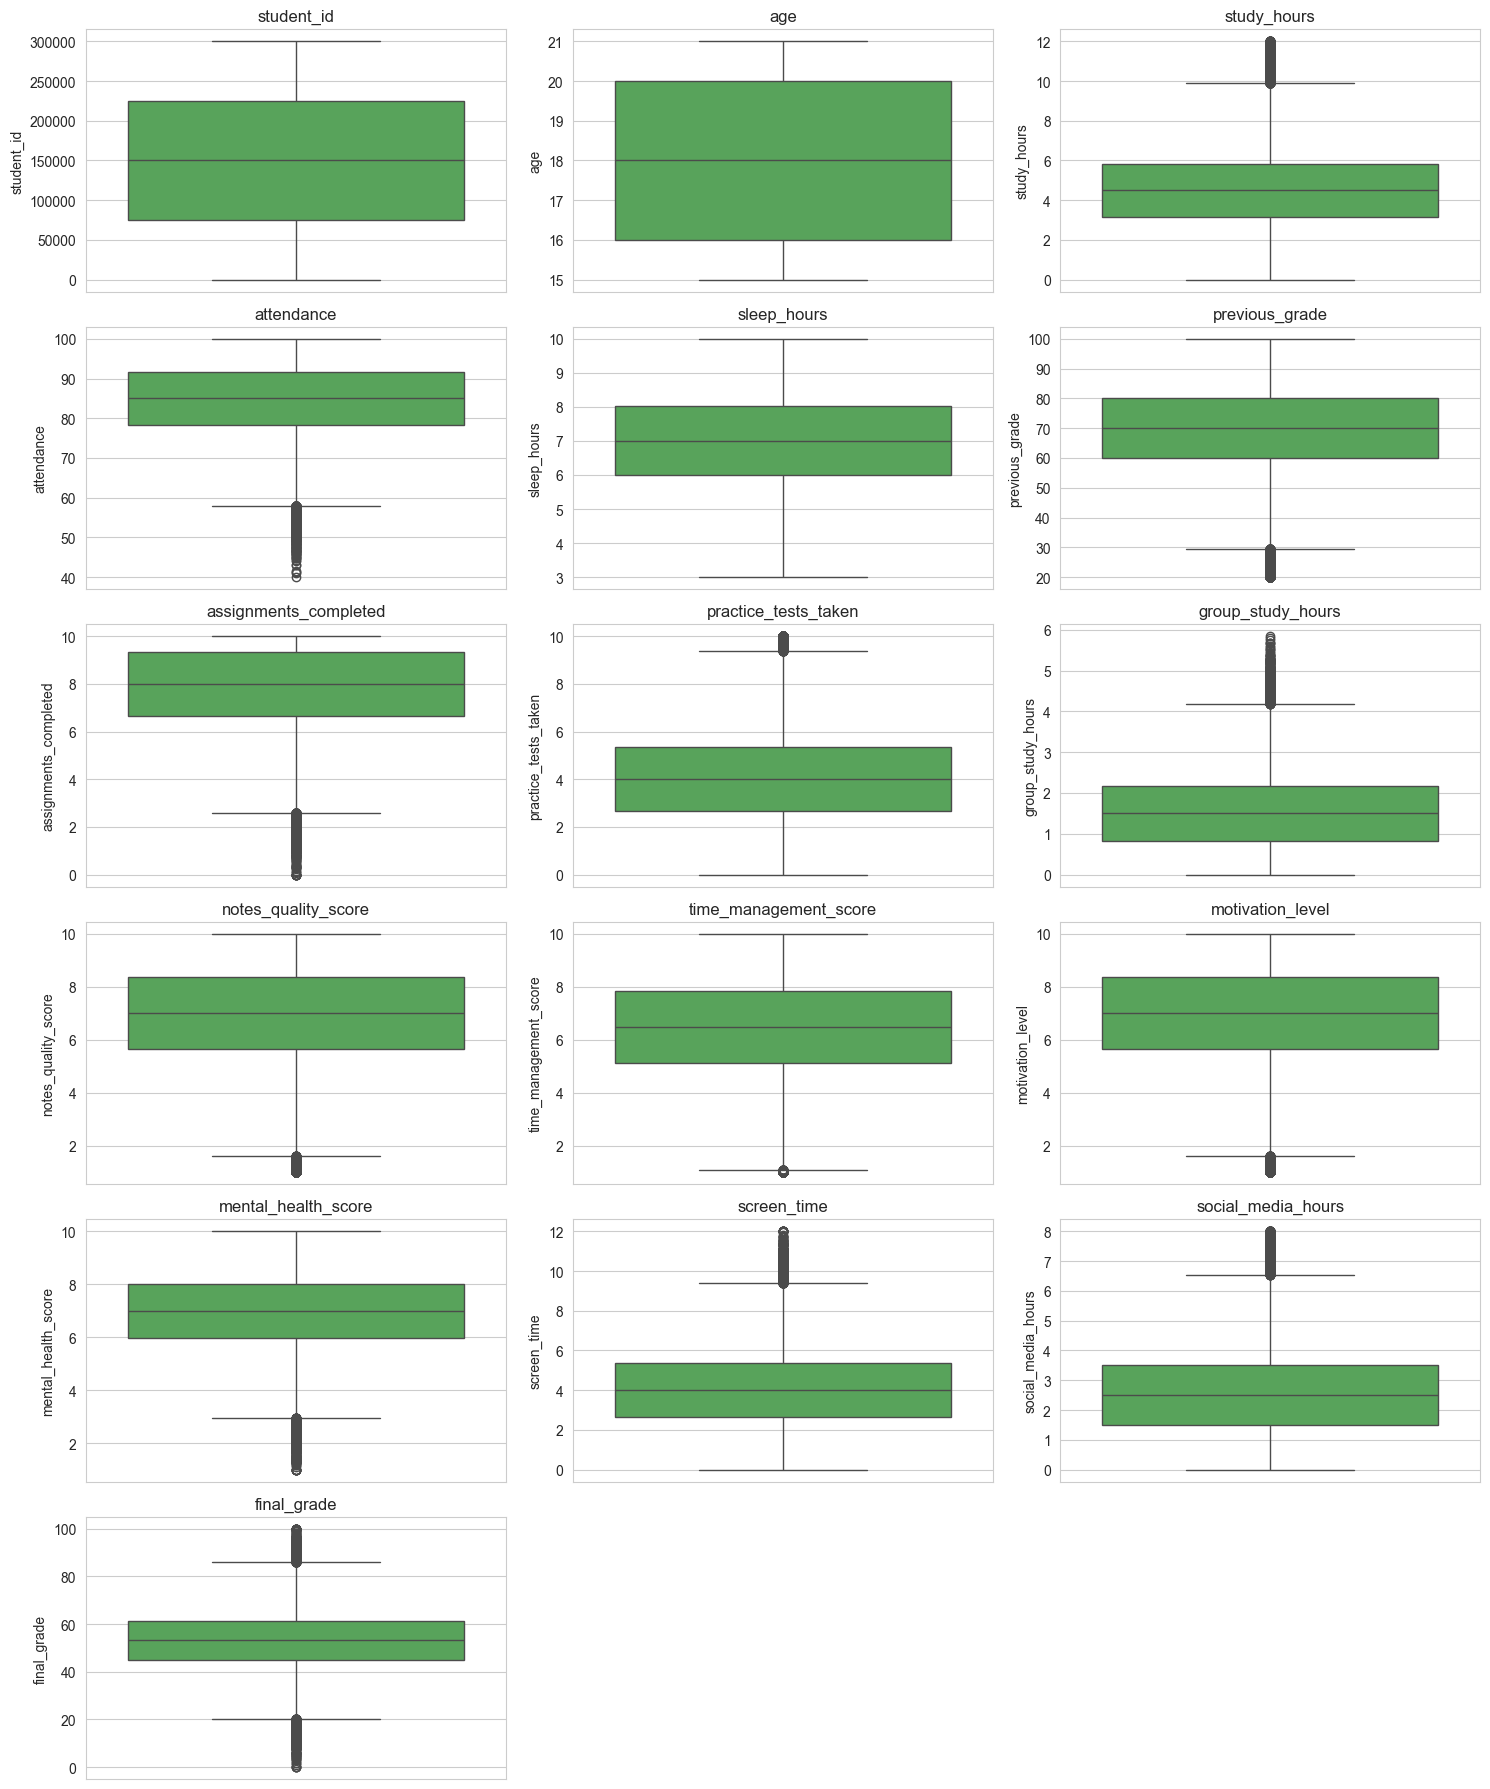

In [62]:
# Box plots for all numerical features to visualize their distributions and identify outliers.
num_cols = df.select_dtypes(include=['int64','float64']).columns
n = len(num_cols)
cols = 3 # Number of columns for the subplot grid
rows = math.ceil(n / cols) # Calculate the number of rows needed for the subplots
plt.figure(figsize=(15, rows * 3))
for i, col in enumerate(num_cols):
    plt.subplot(rows, cols, i+1)
    sns.boxplot(y=df[col], color="#4CAF50") 
    plt.title(col)

plt.tight_layout()
plt.show()

In [63]:
# their exist outliers in the data but we will not remove them because they might be important for the model to learn from them and also we have a large dataset so it will not affect the model performance much.

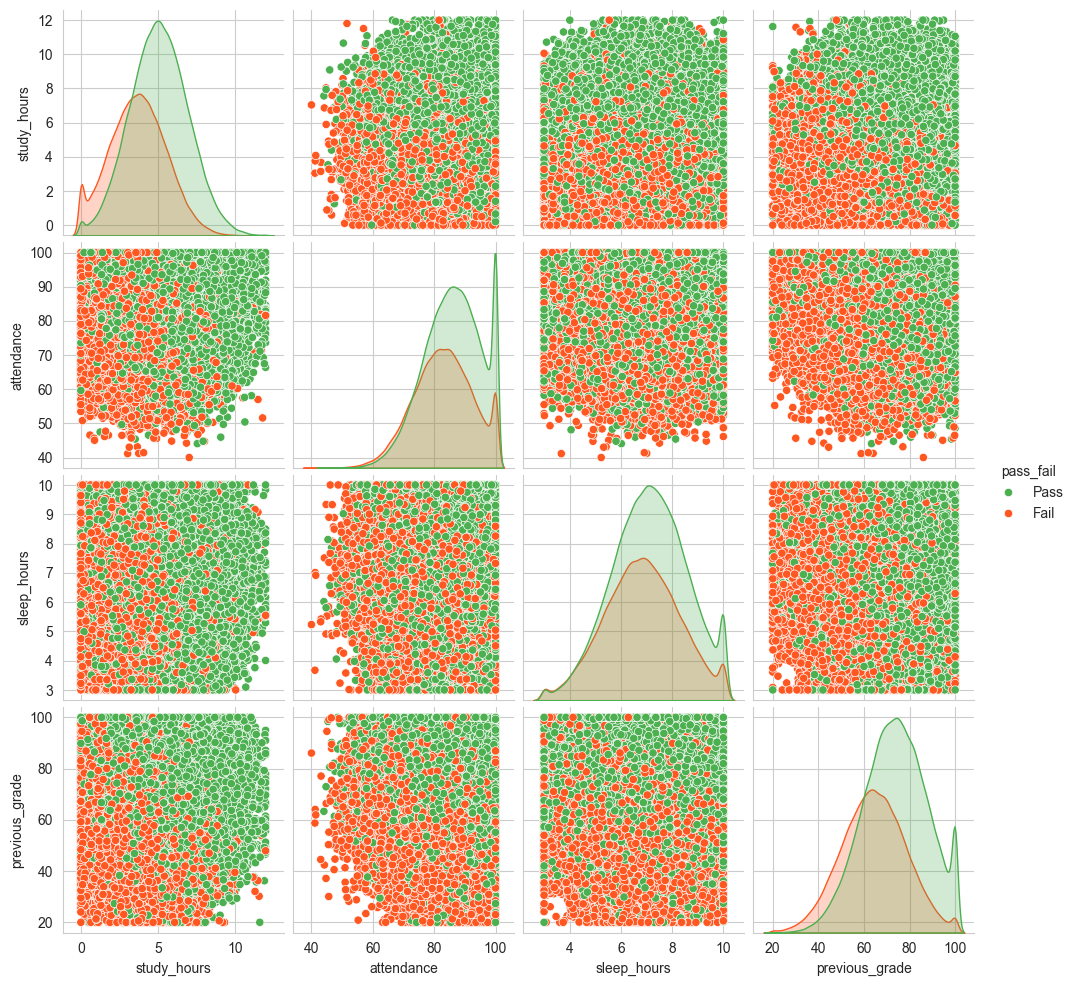

In [64]:
# To visualize the relationships between the target  and the numerical features
sns.pairplot(df[['study_hours','attendance','sleep_hours','previous_grade','pass_fail']], hue='pass_fail', palette=["#4CAF50", "#FF5722"])
plt.show()

___

<h2 style="color:#4CAF50; font-weight:bold;">
3- Data Preprocessing
</h2>

<hr style="border: 2px solid #4CAF50; width: 25%; margin-left:0;">

In [9]:
# Not important column = > student_id 
df.drop(columns=["student_id", "extracurriculars"], inplace=True)
#(extracurriculars) This feature has nearly identical pass/fail distribution across all categories,
# so it provides little to no useful information for prediction and will be removed.

In [10]:
df = df.dropna(subset=["grade_category"])
df["device_type"] = df["device_type"].fillna(df["device_type"].mode()[0])

In [11]:
df.head()

,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,final_grade,grade_category,pass_fail
0,21,Male,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,6.811654,7.316867,9.045441,7.762145,1.549443,4.018412,Medium,Master,Yes,Mobile,Private,59.248749,D,Pass
1,18,Male,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,10.000000,10.000000,9.810884,4.229670,5.458155,3.268642,Medium,Master,Yes,Laptop,Public,58.595595,D,Pass
2,19,Female,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,6.484908,3.618888,10.000000,7.583075,0.000000,2.327293,Low,High School,Yes,Tablet,Private,85.855289,A,Pass
3,21,Female,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,6.057978,5.366866,5.935404,4.978907,5.325794,1.163367,Medium,Bachelor,Yes,Laptop,Public,42.117503,F,Fail
4,17,Male,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,9.013332,5.613393,5.431089,5.677695,4.416843,0.411183,High,High School,Yes,Laptop,Private,62.870474,C,Pass


<h3 style="color:#FF5722; font-weight:bold;">
=> Data Splitting
</h3>

In [12]:
x = df.drop(["pass_fail", "final_grade", "grade_category"], axis=1)

y_pass = df["pass_fail"]
y_final = df["final_grade"]

In [13]:
x_train, x_test, y_pass_train, y_pass_test, y_final_train, y_final_test = train_test_split(
    x, y_pass, y_final,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(df["grade_category"].value_counts())

grade_category
F     119267
D      94434
C      61495
B      20910
A       3593
A+       297
Name: count, dtype: int64


<h3 style="color:#FF5722; font-weight:bold;">
=> Data Encoding 
</h3>

In [15]:
# _____________________________________________ Binary Columns → LabelEncoder ______________________________________________

binary_cols = ["gender", "internet_access", "school_type"]

bin_encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col])
    x_test[col] = le.transform(x_test[col])
    bin_encoders[col] = le
 
# _____________________________________________ Ordinal Columns → OrdinalEncoder __________________________________________

ordinal_config = {
    "family_income": ["Low", "Medium", "High"],
    "parent_education": ["High School", "Bachelor", "Master", "PhD"],
}

ord_encoders = {}

for col, order in ordinal_config.items():
    oe = OrdinalEncoder(categories=[order])
    
    x_train[[col]] = oe.fit_transform(x_train[[col]])
    x_test[[col]] = oe.transform(x_test[[col]])
    
    ord_encoders[col] = oe

#  _____________________________________________ Nominal Columns → One-Hot Encoding _______________________________________

nominal_cols = ["device_type"]

x_train = pd.get_dummies(x_train, columns=nominal_cols, drop_first=True)
x_test = pd.get_dummies(x_test, columns=nominal_cols, drop_first=True)
x_train, x_test = x_train.align(x_test, join="left", axis=1, fill_value=0)

#  _____________________________________________ Target Variables Encoding (Pass/Fail) _______________________________________

le_pass = LabelEncoder()

y_pass_train = le_pass.fit_transform(y_pass_train)
y_pass_test = le_pass.transform(y_pass_test)



In [16]:
x_train.head()

,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,family_income,parent_education,internet_access,school_type,device_type_Mobile,device_type_Tablet
83577,19,1,2.960118,79.203603,5.882637,70.992410,8.627588,5.546531,0.000000,8.240909,6.956038,7.834667,7.431748,5.245837,2.462431,1.0,0.0,1,1,False,False
237955,15,1,4.461097,83.201238,8.265877,48.396600,3.962117,8.054146,0.832135,6.785475,8.846547,8.716614,5.600620,6.710575,5.289144,1.0,2.0,1,1,False,False
5013,18,0,2.262947,84.209602,9.100305,71.781683,9.333991,0.575702,1.733634,6.162281,5.655398,5.693789,4.174923,2.499264,2.567122,0.0,0.0,1,1,False,False
44964,19,1,5.929929,81.075043,6.292394,79.610501,9.854279,2.418679,0.555476,7.020640,7.127989,5.867491,8.599151,6.175862,0.364881,0.0,0.0,1,0,True,False
86935,19,1,2.786927,93.036934,7.308292,92.462619,8.809703,4.165183,3.762053,8.252674,5.221608,7.499024,6.751481,5.917984,2.437106,2.0,1.0,1,0,False,False


In [17]:
# check the shape of the splits to ensure everything is correct
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_pass_train shape:", y_pass_train.shape)
print("y_pass_test shape:", y_pass_test.shape)
print("y_final_train shape:", y_final_train.shape)
print("y_final_test shape:", y_final_test.shape)

x_train shape: (239996, 21)
x_test shape: (60000, 21)
y_pass_train shape: (239996,)
y_pass_test shape: (60000,)
y_final_train shape: (239996,)
y_final_test shape: (60000,)


<h2 style="text-align:center; color:#4CAF50; font-weight:bold;">
Model Building
</h2>

<hr style="border: 2px solid #4CAF50; width: 50%; margin: auto;">

<h4 style="color:#FF5722; font-weight:bold;">
=> Binary Classification: Pass or Fail
</h4>

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [19]:
lr_pass = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_pass.fit(x_train, y_pass_train)

y_pred_lr = lr_pass.predict(x_test)

print("Logistic Regression Accuracy:", accuracy_score(y_pass_test, y_pred_lr))
print(classification_report(y_pass_test, y_pred_lr))

Logistic Regression Accuracy: 0.8679666666666667
              precision    recall  f1-score   support

           0       0.81      0.87      0.84     23624
           1       0.91      0.86      0.89     36376

    accuracy                           0.87     60000
   macro avg       0.86      0.87      0.86     60000
weighted avg       0.87      0.87      0.87     60000



In [20]:
dt_pass = DecisionTreeClassifier(random_state=42)
dt_pass.fit(x_train, y_pass_train)

y_pred_dt = dt_pass.predict(x_test)

print("Decision Tree Accuracy:", accuracy_score(y_pass_test, y_pred_dt))
print(classification_report(y_pass_test, y_pred_dt))

Decision Tree Accuracy: 0.7584333333333333
              precision    recall  f1-score   support

           0       0.69      0.70      0.70     23624
           1       0.80      0.80      0.80     36376

    accuracy                           0.76     60000
   macro avg       0.75      0.75      0.75     60000
weighted avg       0.76      0.76      0.76     60000



In [21]:
rf_pass = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_pass.fit(x_train, y_pass_train)

y_pred_rf = rf_pass.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_pass_test, y_pred_rf))
print(classification_report(y_pass_test, y_pred_rf))

Random Forest Accuracy: 0.85315
              precision    recall  f1-score   support

           0       0.81      0.82      0.81     23624
           1       0.88      0.88      0.88     36376

    accuracy                           0.85     60000
   macro avg       0.85      0.85      0.85     60000
weighted avg       0.85      0.85      0.85     60000



In [47]:
svm_pass = LinearSVC(random_state=42)
svm_pass.fit(x_train, y_pass_train)

y_pass_pred_svm = svm_pass.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_pass_test, y_pass_pred_svm))
print(classification_report(y_pass_test, y_pass_pred_svm))

SVM Accuracy: 0.87165
              precision    recall  f1-score   support

           0       0.84      0.83      0.84     23624
           1       0.89      0.90      0.89     36376

    accuracy                           0.87     60000
   macro avg       0.87      0.86      0.87     60000
weighted avg       0.87      0.87      0.87     60000



In [37]:
results = {
    "Logistic Regression": accuracy_score(y_pass_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_pass_test, y_pred_dt),
    "Random Forest": accuracy_score(y_pass_test, y_pred_rf),
    "SVM": accuracy_score(y_pass_test, y_pass_pred_svm)
}
    
results_df = pd.DataFrame(list(results.items()), columns=["Classification Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=True)  
results_df

,Classification Model,Accuracy
1,Decision Tree,0.758433
2,Random Forest,0.853150
0,Logistic Regression,0.867967
3,SVM,0.871650


<h4 style="color: #eb7956; font-weight:bold;">
-> The best model for Pass/Fail Classification problem (SVM)
</h4>

In [38]:
# best model is SVM for pass classifier
print("SVM Accuracy:", accuracy_score(y_pass_test, y_pass_pred_svm), "\n")

print("Classification Report for SVM:")
print(classification_report(y_pass_test, y_pass_pred_svm))

SVM Accuracy: 0.87165 

Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84     23624
           1       0.89      0.90      0.89     36376

    accuracy                           0.87     60000
   macro avg       0.87      0.86      0.87     60000
weighted avg       0.87      0.87      0.87     60000



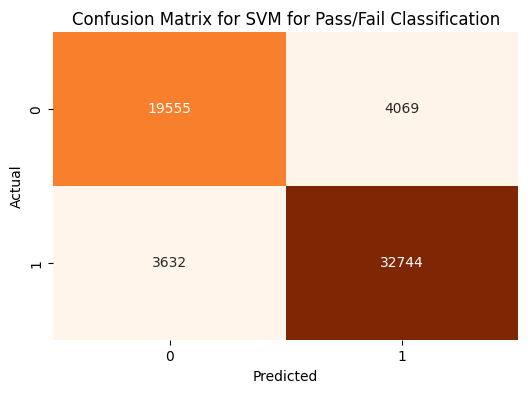

In [39]:
# confusion matrix for SVM (Pass/ Fail)
cm = confusion_matrix(y_pass_test, y_pass_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False)
plt.title("Confusion Matrix for SVM for Pass/Fail Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()  

C:\Users\e\AppData\Local\Temp\ipykernel_19684\3744804718.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=correct, palette=["#F33900", "#B14514"])


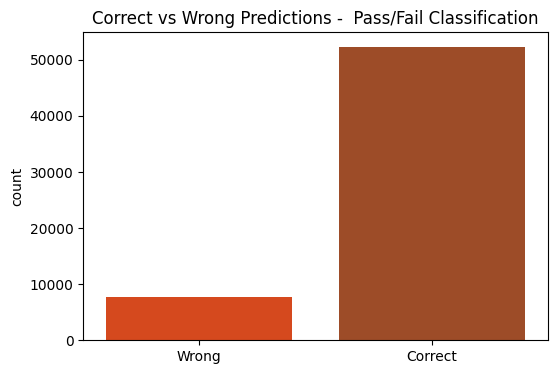

In [61]:
correct = (y_pass_test == y_pass_pred_svm).astype(int)
plt.figure(figsize=(6,4))

sns.countplot(x=correct, palette=["#F33900", "#B14514"])

plt.xticks([0,1], ["Wrong", "Correct"])
plt.title("Correct vs Wrong Predictions -  Pass/Fail Classification")

plt.show()

In [41]:
# save the model using joblib
import joblib
joblib.dump(svm_pass, "svm_pass_model.joblib")

['svm_pass_model.joblib']

<hr style="border: 1px solid #FF5722; width: 50%; margin: auto;">

<h4 style="color:#FF5722; font-weight:bold;">
=> Final Grade Prediction (Regression)
</h4>

In [43]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

In [44]:
lr_final = LinearRegression()
lr_final.fit(x_train, y_final_train)
y_final_pred_lr = lr_final.predict(x_test)

In [45]:
dt_final = DecisionTreeRegressor(
    max_depth=None,       
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

dt_final.fit(x_train, y_final_train)
y_final_pred_dt = dt_final.predict(x_test)

In [46]:
svm_final = LinearSVR(random_state=42)
svm_final.fit(x_train, y_final_train)
y_final_pred_svm = svm_final.predict(x_test)

In [48]:
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2

lr_mse, lr_rmse, lr_r2 = evaluate(y_final_test, y_final_pred_lr)
dt_mse, dt_rmse, dt_r2 = evaluate(y_final_test, y_final_pred_dt)
svm_mse, svm_rmse, svm_r2 = evaluate(y_final_test, y_final_pred_svm)

In [49]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "SVM"],
    "MAE": [lr_mse, dt_mse, svm_mse],
    "RMSE": [lr_rmse, dt_rmse, svm_rmse],
    "R2 Score": [lr_r2, dt_r2, svm_r2]
})

results_sorted = results.sort_values(by="R2 Score")  
print(results_sorted)

               Model        MAE      RMSE  R2 Score
1      Decision Tree  84.353728  9.184429  0.430950
0  Linear Regression  24.968828  4.996882  0.831560
2                SVM  24.967735  4.996773  0.831568


<h4 style="color: #eb7956; font-weight:bold;">
-> The best model for Final Grade Prediction (SVM)
</h4>

In [50]:
# best model is svm for final grade regression
print("SVM Regression Performance:")
print(f"MAE: {svm_mse:.2f}")
print(f"RMSE: {svm_rmse:.2f}")
print(f"R2 Score: {svm_r2:.4f}")

SVM Regression Performance:
MAE: 24.97
RMSE: 5.00
R2 Score: 0.8316


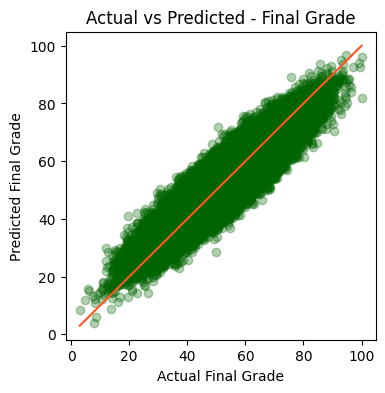

In [67]:
plt.figure(figsize=(4,4))

plt.scatter(y_final_test, y_final_pred_svm, alpha=0.3, color="darkgreen")

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted - Final Grade")

plt.plot([y_final_test.min(), y_final_test.max()],
         [y_final_test.min(), y_final_test.max()],
         color="#FF5722")

plt.show()


In [68]:
#save the model using joblib
joblib.dump(svm_final, "svm_final_grade_model.joblib")

['svm_final_grade_model.joblib']